<a href="https://colab.research.google.com/github/kosebaris1/MACHINE_LEARNING/blob/CNN/CNN_Rock_Paper_Scissors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

dataset, info = tfds.load("rock_paper_scissors", as_supervised=True, with_info=True)
train_ds = dataset["train"]
test_ds = dataset["test"]
class_names = info.features["label"].names
print("Sınıflar:", class_names)


Sınıflar: ['rock', 'paper', 'scissors']


In [13]:
IMG_SIZE = 128
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(preprocess).shuffle(1000).batch(32, drop_remainder=True)
test_ds = test_ds.map(preprocess).batch(32, drop_remainder=True)


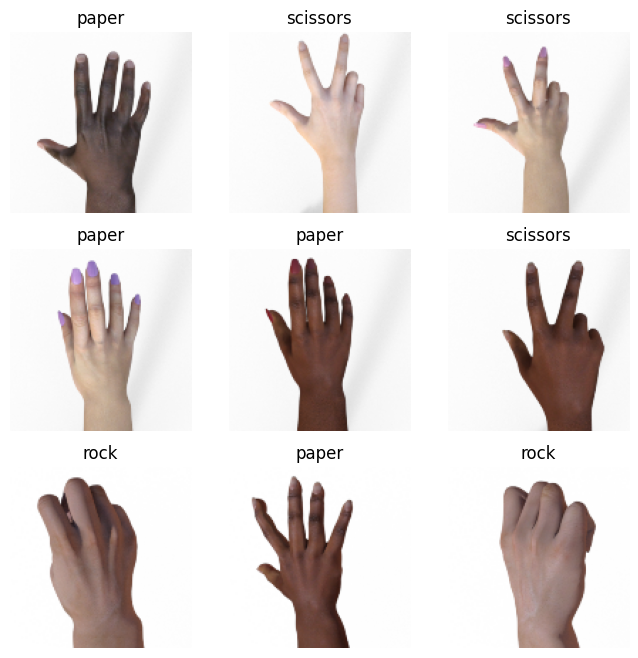

In [14]:
plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[int(labels[i].numpy())])
        plt.axis("off")
plt.show()


In [21]:
from tensorflow.keras import layers, models, regularizers

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_ds, epochs=15, validation_data=test_ds)


Epoch 1/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.5658 - loss: 1.0621 - val_accuracy: 0.8523 - val_loss: 0.5840
Epoch 2/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9786 - loss: 0.1948 - val_accuracy: 0.9148 - val_loss: 0.3738
Epoch 3/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9922 - loss: 0.1088 - val_accuracy: 0.8551 - val_loss: 0.5325
Epoch 4/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9926 - loss: 0.1031 - val_accuracy: 0.8949 - val_loss: 0.4341
Epoch 5/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9981 - loss: 0.0750 - val_accuracy: 0.8608 - val_loss: 0.5006
Epoch 6/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9978 - loss: 0.0687 - val_accuracy: 0.8920 - val_loss: 0.4203
Epoch 7/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9958 - loss: 0.0748 - val_accuracy: 0.8920 - val_loss: 0.4880
Epoch 8/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9918 - loss: 0.0740 - val_accuracy: 0.9119 - v

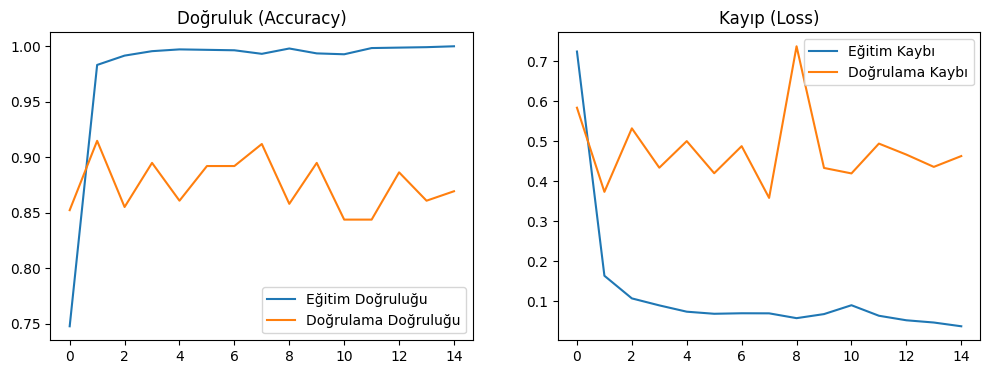

In [22]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.legend()
plt.title("Doğruluk (Accuracy)")

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.legend()
plt.title("Kayıp (Loss)")

plt.show()


In [23]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test doğruluk oranı: %{test_acc * 100:.2f}")


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8893 - loss: 0.4198
Test doğruluk oranı: %86.93


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step


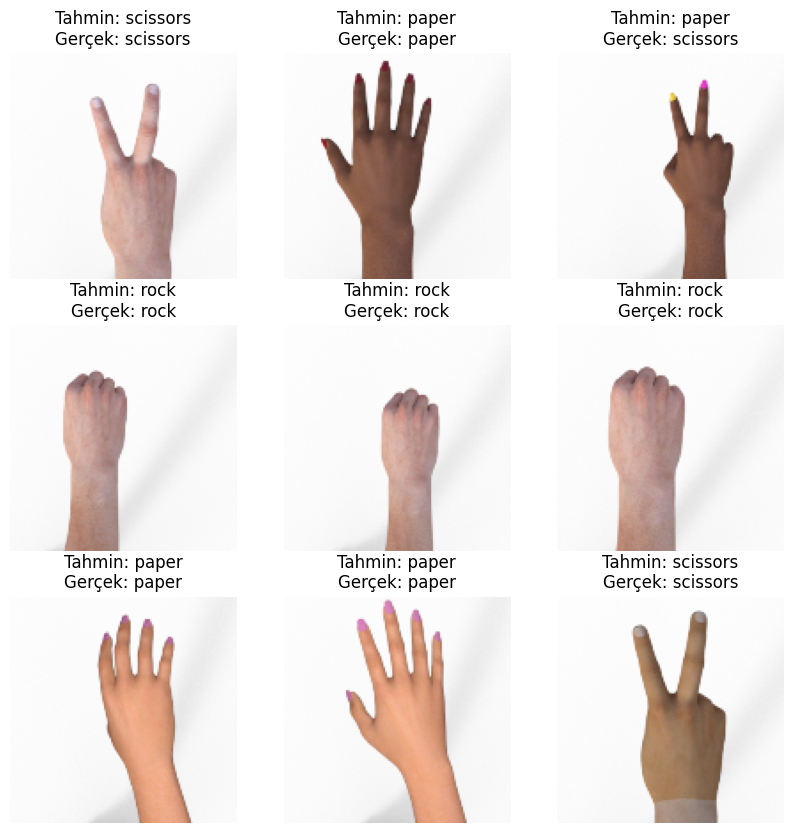

In [24]:
for images, labels in test_ds.take(1):
    preds = model.predict(images)
    pred_classes = np.argmax(preds, axis=1)

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy())
    plt.title(f"Tahmin: {class_names[pred_classes[i]]}\nGerçek: {class_names[int(labels[i].numpy())]}")
    plt.axis("off")
plt.show()
